# Readme

Plot all functional and retina edge recordings.
Connect the edge recordings to show the outline of the Retina.
Note that the first edge recording is actually the optic disc.

In [1]:
import os

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data_folder = "../../data/preprocessed-data"

# df_rois = pd.concat([pd.read_hdf(os.path.join(data_folder, f'df_eyewire2_roi_level_GCL{i}.h5'), key='dataframe') for i in range(5)])
df_fields = pd.read_hdf(os.path.join(data_folder, 'df_eyewire2_field_level.h5'), key='dataframe')
df_outline = pd.read_hdf(os.path.join(data_folder, 'df_eyewire2_outline.h5'), key='dataframe')

In [65]:
def plot_stack_average(ax, stack_avg, pixel_size_um, x_offset, y_offset, cmap='viridis', alpha=0.7, gamma=0.5):
    ps = pixel_size_um
    w, h = stack_avg.shape[:2]
    assert w == h
    extent = np.array([-w / 2 * ps, +w / 2 * ps, -w / 2 * ps, +w / 2 * ps])
    extent += (x_offset, x_offset, y_offset, y_offset)

    im = stack_avg.astype(float)
    vmin = np.percentile(im, q=5, axis=(0, 1))
    vmax = np.percentile(im, q=99, axis=(0, 1))
    im = (im - vmin) / (vmax - vmin)
    im = np.clip(im, 0, 1) ** gamma

    ax.imshow(im.T, extent=extent, cmap=cmap, interpolation='none', alpha=alpha)

    return extent

In [66]:
fig_dir = './figures/retinal_locations'
os.makedirs(fig_dir, exist_ok=True)

In [67]:
def plot_retina_orientation(ax, tdist=50, x0=0, y0=0, size=1000, fontsize=14):
    ax.plot([x0 - size / 2, x0 + size / 2], [y0, y0], c='k', dash_capstyle='butt', clip_on=False)
    ax.plot([x0, x0], [y0 - size / 2, y0 + size / 2], c='k', dash_capstyle='butt', clip_on=False)
    ax.text(x0 - size / 2 - tdist, y0, 'N', c='k', va='center', ha='right', fontsize=fontsize)
    ax.text(x0 + size / 2 + tdist, y0, 'T', c='k', va='center', ha='left', fontsize=fontsize)
    ax.text(x0, y0 - size / 2 - tdist, 'V', c='k', va='top', ha='center', fontsize=fontsize)
    ax.text(x0, y0 + size / 2 + tdist, 'D', c='k', va='bottom', ha='center', fontsize=fontsize)


def plot_scale_bar(ax, x0=0, y0=0, size=1000, tdist=70, fontsize=14):
    ax.plot([-size / 2 + x0, +size / 2 + x0], [y0, y0], c='k', dash_capstyle='butt', clip_on=False)
    ax.text(x0, y0 - tdist, f'{size / 1000:.0f} mm', c='k', va='top', ha='center', fontsize=fontsize)

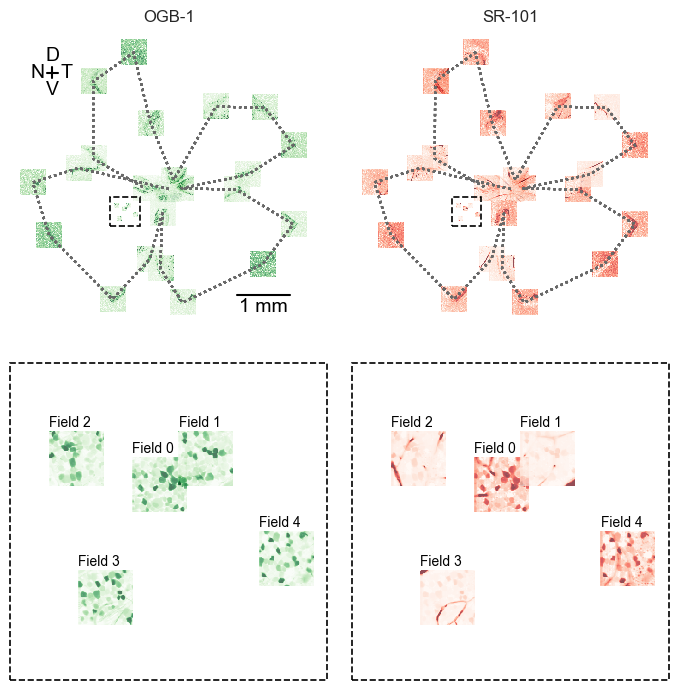

In [68]:
cmaps = ['Greens', 'Reds']
color_crop = 'k'

fig, axs_all = plt.subplots(2, 2, figsize=(7, 7), sharey='row', sharex='row')

axs = axs_all[0, :]
for i, row in df_outline.iterrows():
    for j, ax in enumerate(axs):
        plot_stack_average(
            ax, row['stack_averages'][:, :, j],
            row['pixel_size_um'],
            row['temporal_nasal_pos_um'], row['ventral_dorsal_pos_um'],
            cmap=cmaps[j])

    for ax in axs:
        ax.set(xlim=(-3000, 3000), ylim=(-3000, 3000))
        #ax.set(xlabel='Temporal <-> Nasal [um]', ylabel='Ventral <-> Dorsal [um]')
        ax.plot(df_outline['temporal_nasal_pos_um'],
                df_outline['ventral_dorsal_pos_um'], c='dimgray', ls=':')
        ax.axis('off')
        #ax.grid()
        ax.set_aspect('equal')

for axs in axs_all:
    for i, row in df_fields.iterrows():
        for j in [0, 1]:
            if axs[j] in axs_all[1, :]:
                axs[j].text(row['field_temporal_nasal_pos_um'] - 10, row['field_ventral_dorsal_pos_um'] + 50,
                            'Field ' + row.field[-1], c='k', va='bottom', ha='center')
            plot_stack_average(
                axs[j], row[f'ch{j}_average'],
                row['pixel_size_um'],
                row['field_temporal_nasal_pos_um'], row['field_ventral_dorsal_pos_um'],
                cmap=cmaps[j])
box_xlim = (-1100, -550)
box_ylim = (-700, -150)
for ax in axs_all[1, :]:
    ax.set(xlim=box_xlim, ylim=box_ylim)
    #ax.set(xlabel='Retinal location [µm]\nTemporal ↔ Nasal', ylabel='Position [µm]\nVentral ↔ Dorsal')
    ax.axis('off')
    #ax.grid()
    ax.set_aspect('equal')

for ax in axs_all.flat:
    rect = patches.Rectangle(
        (box_xlim[0], box_ylim[0]), box_xlim[1] - box_xlim[0], box_ylim[1] - box_ylim[0],
        linewidth=1.2, edgecolor=color_crop, facecolor='none', linestyle='--', clip_on=False
    )
    ax.add_patch(rect)

plot_retina_orientation(ax=axs_all[0, 0], tdist=50, x0=-2200, y0=2200, size=200)
plot_scale_bar(ax=axs_all[0, 0], x0=1800, y0=-2000, size=1000, tdist=70)

axs_all[0, 0].set_title('OGB-1')
axs_all[0, 1].set_title('SR-101')

plt.savefig(os.path.join(fig_dir, 'erm_retinal_field_locations.pdf'))
plt.tight_layout()
plt.show()

In [91]:
def make_square_bounding_box(xs, ys):
    # Step 1: Find initial min and max
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    # Step 2: Determine width and height
    width = xmax - xmin
    height = ymax - ymin

    # Step 3: Expand the smaller side to match the larger
    if width > height:
        # Increase height
        diff = width - height
        ymin -= diff / 2
        ymax += diff / 2
    elif height > width:
        # Increase width
        diff = height - width
        xmin -= diff / 2
        xmax += diff / 2

    return xmin, xmax, ymin, ymax


In [92]:
def plot_roi_mask(ax, rois, extent):
    _rois = -rois.copy()
    _rois = _rois.astype(float)
    _rois[_rois <= 0] = np.nan
    _rois = np.repeat(np.repeat(_rois, 3, axis=0), 3, axis=0)
    ax.imshow(_rois.T, cmap='jet', extent=extent)

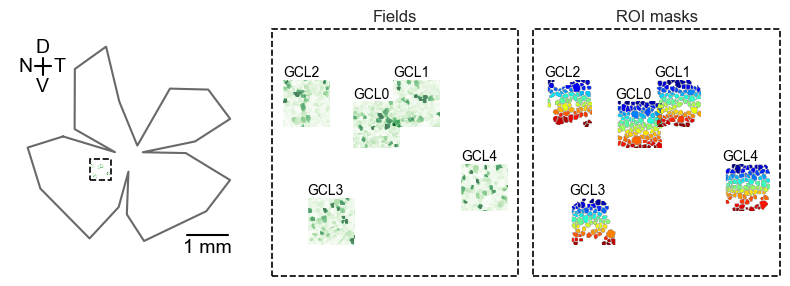

In [100]:
cmaps = ['Greens', 'Reds']
color_crop = 'k'

fig, axs = plt.subplots(1, 3, figsize=(8, 3))

for ax in axs:
    ax.axis('off')
    ax.set_aspect('equal')

j = 0
ax = axs[0]
ax.set(xlim=(-3000, 3000), ylim=(-3000, 3000))
ax.plot(np.append(df_outline['temporal_nasal_pos_um'].values[1:], df_outline['temporal_nasal_pos_um'].values[1]),
        np.append(df_outline['ventral_dorsal_pos_um'].values[1:], df_outline['ventral_dorsal_pos_um'].values[1]),
        c='dimgray', ls='-')

xmin, xmax, ymin, ymax = make_square_bounding_box(df_fields['field_temporal_nasal_pos_um'], df_fields['field_ventral_dorsal_pos_um'])

box_xlim = (xmin-70, xmax+70)
box_ylim = (ymin-50, ymax+90)

axs[1].set_title('Fields')
axs[2].set_title('ROI masks')

for i, row in df_fields.iterrows():
    for ii in [0, 1]:
        ax = axs[ii]
        extent = plot_stack_average(
            ax, row[f'ch{j}_average'],
            row['pixel_size_um'],
            row['field_temporal_nasal_pos_um'], row['field_ventral_dorsal_pos_um'],
            cmap=cmaps[j])

    for ii in [1, 2]:
        ax = axs[ii]
        ax.text(row['field_temporal_nasal_pos_um'] - 10, row['field_ventral_dorsal_pos_um'] + 50,
                    row['field'], c='k', va='bottom', ha='center')
        ax.set(xlim=box_xlim, ylim=box_ylim)

    ax = axs[2]
    plot_roi_mask(ax, rois=row['roi_mask'], extent=extent)

for ax in axs.flat:
    rect = patches.Rectangle(
        (box_xlim[0], box_ylim[0]), box_xlim[1] - box_xlim[0], box_ylim[1] - box_ylim[0],
        linewidth=1.2, edgecolor=color_crop, facecolor='none', linestyle='--', clip_on=False
    )
    ax.add_patch(rect)

plot_retina_orientation(ax=axs[0], tdist=50, x0=-2200, y0=2100, size=400)
plot_scale_bar(ax=axs[0], x0=1800, y0=-2000, size=1000, tdist=70)

plt.savefig(os.path.join(fig_dir, 'erm_retinal_field_locations.svg'), dpi=450, bbox_inches='tight')
plt.tight_layout()
plt.show()